# Logistic Regression Project - Breast Cancer Dataset

The goal of this notebook is to use Scikit-Learn's and from scratch logistic regression models to implement a complete machine learning project using **Scikit-Learn's breast cancer dataset**.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, classification_report, roc_curve, auc

import matplotlib.pyplot as plt

import joblib

from logistic_regression import LogisticRegression as LogisticRegressionScratch

## 2. Load dataset

In [2]:
df = pd.DataFrame(load_breast_cancer().data, columns=load_breast_cancer().feature_names)
df['target'] = load_breast_cancer().target # binary classification: malignant or benign

In [3]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
df.info(), df.describe(), df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

(None,
        mean radius  mean texture  mean perimeter    mean area  \
 count   569.000000    569.000000      569.000000   569.000000   
 mean     14.127292     19.289649       91.969033   654.889104   
 std       3.524049      4.301036       24.298981   351.914129   
 min       6.981000      9.710000       43.790000   143.500000   
 25%      11.700000     16.170000       75.170000   420.300000   
 50%      13.370000     18.840000       86.240000   551.100000   
 75%      15.780000     21.800000      104.100000   782.700000   
 max      28.110000     39.280000      188.500000  2501.000000   
 
        mean smoothness  mean compactness  mean concavity  mean concave points  \
 count       569.000000        569.000000      569.000000           569.000000   
 mean          0.096360          0.104341        0.088799             0.048919   
 std           0.014064          0.052813        0.079720             0.038803   
 min           0.052630          0.019380        0.000000            

In [5]:
print("Shape:\n", df.shape)
print("Head:\n", df.head())
print("Description:\n", df.describe())
print("Null Values:\n", df.isnull().sum())

Shape:
 (569, 31)
Head:
    mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  wor

Clean dataset with **no missing values, 30 numerical features and 569 samples**.

We also notice that for the target, the mean is 0.627 meaning that ~63% of samples are class 1 (benign) and ~37% of them Class 0 (malignant). 

The **dataset is slightly imbalanced**. Not critically so, but it means that accuracy alone isn’t a sufficient metric. A model that always predicts 1 would already have 63% accuracy without learning anything.

That’s why we'll also look at precision, recall, and F1 score in the evaluation, especially for class 0 (malignant), where a false negative is clinically dangerous.

## 3. Train and test datasets

In [6]:
# Prepare the data: target variable and features
X = df.drop("target", axis=1).values # features
y = df["target"].values # target

In [7]:
# Split datasets into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Why scaling the features?**

During the gradient descent:

$$
w \leftarrow w - \alpha \cdot \frac{1}{n} X^T(\hat{y} - y)
$$

The gradient:

$$
\frac{1}{n} X^T(\hat{y} - y)
$$

depends directly on the values of $X$.  

If *mean area* is around 500 and *mean smoothness* is around 0.05, their gradients will have completely different magnitudes and the weight associated with *mean area* will oscillate significantly during training, while the one for *mean smoothness* will barely move.

Result: slow and unstable convergence, and a learning rate that is difficult to tune.

Feature scaling normalizes all features to the same scale, allowing gradient descent to converge much more smoothly.

In [8]:
# Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Why scaling only features and separating training and test datasets?**

This is called **data leakage**.

If we apply the scaler to the entire dataset (training + test), the calculated mean and standard deviation contain information about the test set. The model has never “seen” the test set directly, but the scaling has taken it into account.

The test set is supposed to simulate unknown future data. In production, we only have the scaler trained on the training set to transform the new data. So that’s exactly what we need to replicate here.

The rule: train on the training set, transform on the training set, and test.

## 4. Train the model with Logistic Regression model from scratch

In [9]:
# Train and fit the scratch Logistic Regression model
model_scratch = LogisticRegressionScratch(learning_rate=0.01, num_iterations=5000)
model_scratch.fit(X_train_scaled, y_train)

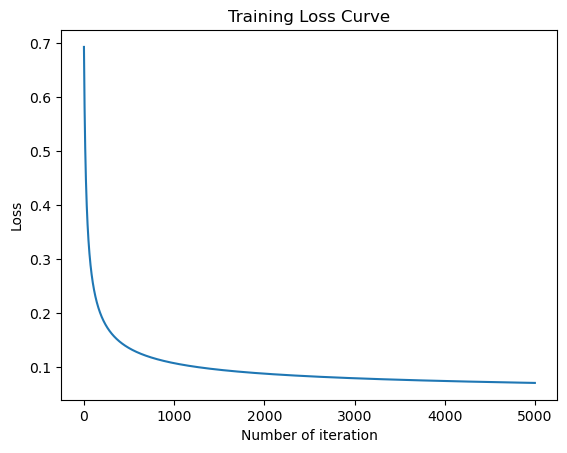

In [10]:
# Visualize the loss history
plt.plot(model_scratch.losses)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

The loss curve converges properly.

In [11]:
# Evaluate the scratch model
# Train set evaluation
predictions_scratch_train = model_scratch.predict(X_train_scaled)
accuracy_scratch_train = accuracy_score(y_train, predictions_scratch_train)
f1_score_scratch_train = f1_score(y_train, predictions_scratch_train)
recall_scratch_train = recall_score(y_train, predictions_scratch_train)

print("Scratch Logistic Regression - Train Accuracy:", accuracy_scratch_train)
print("Scratch Logistic Regression - Train F1 Score:", f1_score_scratch_train)
print("Scratch Logistic Regression - Train Recall:", recall_scratch_train)

Scratch Logistic Regression - Train Accuracy: 0.9868131868131869
Scratch Logistic Regression - Train F1 Score: 0.9895470383275261
Scratch Logistic Regression - Train Recall: 0.993006993006993


In [12]:
# Test set evaluation
predictions_scratch_test = model_scratch.predict(X_test_scaled)
accuracy_scratch_test = accuracy_score(y_test, predictions_scratch_test)
f1_score_scratch_test = f1_score(y_test, predictions_scratch_test)
recall_scratch_test = recall_score(y_test, predictions_scratch_test)

print("Scratch Logistic Regression - Test Accuracy:", accuracy_scratch_test)
print("Scratch Logistic Regression - Test F1 Score:", f1_score_scratch_test)
print("Scratch Logistic Regression - Test Recall:", recall_scratch_test)

Scratch Logistic Regression - Test Accuracy: 0.9824561403508771
Scratch Logistic Regression - Test F1 Score: 0.9859154929577465
Scratch Logistic Regression - Test Recall: 0.9859154929577465


Accuracy (98.2%), f1 (98.6%) and recall for class 1 (benign) (98.6%) scores are excellent.

In [13]:
# Print confusion matrix and classification report for test set
conf_matrix = confusion_matrix(y_test, predictions_scratch_test)
print("Confusion Matrix:\n", conf_matrix)

class_report = classification_report(y_test, predictions_scratch_test)
print("Classification Report:\n", class_report)

Confusion Matrix:
 [[42  1]
 [ 1 70]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        43
           1       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



Confusion matrix:

- 42 true negatives (malignant cases correctly detected)
- 70 true positives (benign cases correctly detected)
- 1 false positive (a malignant case predicted as benign)
- 1 false negative (a benign case predicted as malignant)

The critical figure here is that 1 false positive (a malignant tumor) that went undetected. 

Recall for class 0 = $\frac{TP}{TP + FN} = \frac{42}{1 + 42} = 0.98$, so we miss 1 malignant case out of 43. That’s very good for a model built from scratch.

## 5. Train the model with Logistic Regression from Scikit-Learn

In [14]:
# Train scikit-learn's Logistic Regression model
model_sklearn = LogisticRegression(max_iter=5000)
model_sklearn.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [15]:
# Evaluate scikit-learn model
# Train set evaluation
predictions_sklearn_train = model_sklearn.predict(X_train_scaled)
accuracy_sklearn_train = accuracy_score(y_train, predictions_sklearn_train)
f1_score_sklearn_train = f1_score(y_train, predictions_sklearn_train)
recall_sklearn_train = recall_score(y_train, predictions_sklearn_train)

print("Scikit-learn Logistic Regression - Train Accuracy:", accuracy_sklearn_train)
print("Scikit-learn Logistic Regression - Train F1 Score:", f1_score_sklearn_train)
print("Scikit-learn Logistic Regression - Train Recall:", recall_sklearn_train)

Scikit-learn Logistic Regression - Train Accuracy: 0.9868131868131869
Scikit-learn Logistic Regression - Train F1 Score: 0.9895470383275261
Scikit-learn Logistic Regression - Train Recall: 0.993006993006993


In [16]:
# Test set evaluation
predictions_sklearn_test = model_sklearn.predict(X_test_scaled)
accuracy_sklearn_test = accuracy_score(y_test, predictions_sklearn_test)
f1_score_sklearn_test = f1_score(y_test, predictions_sklearn_test)
recall_sklearn_test = recall_score(y_test, predictions_sklearn_test)

print("Scikit-learn Logistic Regression - Test Accuracy:", accuracy_sklearn_test)
print("Scikit-learn Logistic Regression - Test F1 Score:", f1_score_sklearn_test)
print("Scikit-learn Logistic Regression - Test Recall:", recall_sklearn_test)

Scikit-learn Logistic Regression - Test Accuracy: 0.9736842105263158
Scikit-learn Logistic Regression - Test F1 Score: 0.9790209790209791
Scikit-learn Logistic Regression - Test Recall: 0.9859154929577465


In [17]:
# Print confusion matrix and classification report for test set
conf_matrix_sklearn = confusion_matrix(y_test, predictions_sklearn_test)
print("Confusion Matrix:\n", conf_matrix_sklearn)

class_report_sklearn = classification_report(y_test, predictions_sklearn_test)
print("Classification Report:\n", class_report_sklearn)

Confusion Matrix:
 [[41  2]
 [ 1 70]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



Scratch's implementation outperforms sklearn on this dataset with these hyperparameters.

| Metric            | Scratch | Sklearn |
|------------------|--------:|--------:|
| Accuracy         | 98.2%   | 97.4%   |
| F1 Score         | 0.986   | 0.979   |
| Recall (class 0) | 0.98    | 0.95    |

The key difference: sklearn misclassifies 2 malignant cases, compared to only 1 for our model.

Why this difference?  

Sklearn uses a different solver by default (not pure gradient descent) and applies L2 regularization with $C = 1.0$.  

Our implementation does not include regularization, which, in this case, gives our model an advantage.

## 6. Dataset and decision boundary visualization

In [18]:
# Compute the probabilities for the test set using the scratch model
y_proba_scratch_test = model_scratch.predict_proba(X_test_scaled)

In [19]:
# Compute the probabilities for the test set using scikit-learn model
y_proba_sklearn_test = model_sklearn.predict_proba(X_test_scaled)[:, 1]

In [20]:
# ROC curves
# Scratch model
fpr_scratch, tpr_scratch, _ = roc_curve(y_test, y_proba_scratch_test)
auc_scratch = auc(fpr_scratch, tpr_scratch)

# Sklearn model
fpr_sklearn, tpr_sklearn, _ = roc_curve(y_test, y_proba_sklearn_test)
auc_sklearn = auc(fpr_sklearn, tpr_sklearn)

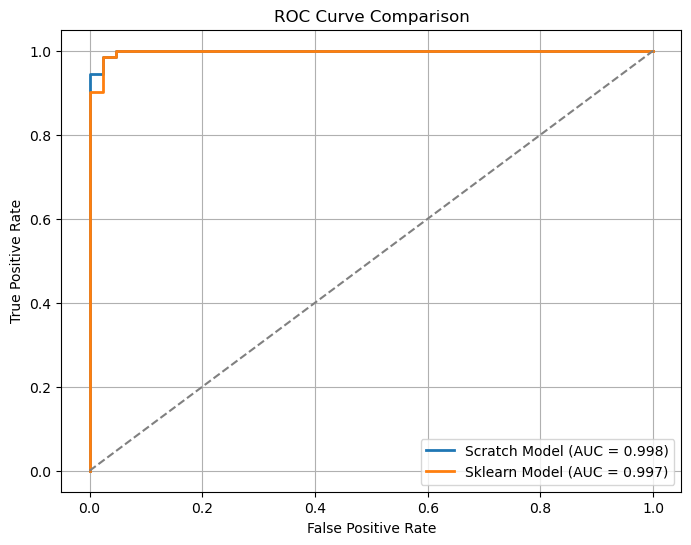

In [21]:
# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_scratch, tpr_scratch, label=f"Scratch Model (AUC = {auc_scratch:.3f})", linewidth=2)
plt.plot(fpr_sklearn, tpr_sklearn, label=f"Sklearn Model (AUC = {auc_sklearn:.3f})", linewidth=2)

# Add a diagonal line for reference (random classifier)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

The diagonal gray line represents a **random classifier**, meaning a model that makes random predictions. If a model lies below this line, it performs worse than chance. The closer the curve is to the top-left corner (FP=0, TP=1), the better the model.

Considering our graph, both curves cluster in the upper-left corner with AUC = 0.998 and 0.997, nearly perfect. 

This means that at virtually any threshold, our models effectively separate the two classes. The small dip visible on the scratch curve around FP=0.05 corresponds to the 2–3 ambiguous cases near the boundary.

## 7. Save models

In [22]:
# Save both models
joblib.dump(model_scratch, "models/logistic_regression_scratch.pkl")
joblib.dump(model_sklearn, "models/logistic_regression_sklearn.pkl")

['models/logistic_regression_sklearn.pkl']

In [23]:
# Verify that the models are saved correctly
loaded_scratch_model = joblib.load("models/logistic_regression_scratch.pkl")
loaded_sklearn_model = joblib.load("models/logistic_regression_sklearn.pkl")

In [24]:
# Predict the test set with the loaded models
predictions_loaded_scratch = loaded_scratch_model.predict(X_test_scaled)
predictions_loaded_sklearn = loaded_sklearn_model.predict(X_test_scaled)

In [25]:
# Compare predictions from loaded models with original predictions
np.allclose(predictions_scratch_test, predictions_loaded_scratch), np.allclose(predictions_sklearn_test, predictions_loaded_sklearn)

(True, True)